# GLM DF Inference 
Here we perform bayesian inference on the dataset generated by IBM simulations with GLM parameterised vital rates 

In [125]:
import pandas as pd
import numpy as np
import jax
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import hpdi
from numpyro.infer import MCMC, NUTS

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('glm_ibm_dataset.csv')

In [4]:
df.describe()

,z,Repr,Seeds,Surv,z1,age,yr
count,560.000000,560.000000,16.000000,544.000000,212.000000,560.000000,560.000000
mean,0.274511,0.028571,1658.000000,0.389706,1.337016,0.519643,2.476786
std,1.064106,0.166748,1812.467636,0.488132,0.828193,0.941760,1.617048
min,-2.299141,0.000000,158.000000,0.000000,-0.938620,0.000000,1.000000
25%,-0.484583,0.000000,842.250000,0.000000,0.776419,0.000000,1.000000
50%,0.141106,0.000000,1039.000000,0.000000,1.389974,0.000000,2.000000
75%,1.038216,0.000000,1512.000000,1.000000,1.894787,1.000000,4.000000
max,3.520590,1.000000,6257.000000,1.000000,3.520590,4.000000,5.000000


In [108]:
def survival_inference_model(s, y, priors):
    intercept = numpyro.sample('surv_int', priors['surv_int'])
    slope = numpyro.sample('surv_slope', priors['surv_slope'])
    mu = intercept + slope * s
    p = jax.nn.sigmoid(mu)
    numpyro.sample('surv', dist.Bernoulli(p), obs = y)

s_surv = df[df['Repr'] == 0]['z'].values
y_surv = df[df['Repr'] == 0]['Surv'].values

In [109]:
def repr_inference_model(s, y, priors):
    intercept = numpyro.sample('repr_int', priors['repr_int'])
    slope = numpyro.sample('repr_slope', priors['repr_slope'])
    mu = intercept + slope * s
    p = jax.nn.sigmoid(mu)
    numpyro.sample('repr', dist.Bernoulli(p), obs = y)

s_repr = df[df['Repr'].notna()]['z'].values
y_repr = df[df['Repr'].notna()]['Repr'].values

In [ ]:
def seed_inference_model(s, y, priors):
    intercept = numpyro.sample('seed_int', priors['seed_int'])
    slope = numpyro.sample('seed_slope', priors['seed_slope'])
    mu = intercept + slope * s
    lambda_ = jnp.exp(mu)
    numpyro.sample('seed', dist.Poisson(lambda_), obs = y)

s_seed = df[df['Seeds'].notna()]['z'].values
y_seed = df[df['Seeds'].notna()]['Seeds'].values

In [117]:
def growth_inference_model(s, y, priors):
    intercept = numpyro.sample('growth_int', priors['growth_int'])
    slope = numpyro.sample('growth_slope', priors['growth_slope'])
    noise = numpyro.sample('growth_noise', priors['growth_noise'])
    mu = intercept + slope * s
    numpyro.sample('z1', dist.Normal(mu, noise), obs = y)

s_growth = df[df['z1'].notna()]['z'].values
y_growth = df[df['z1'].notna()]['z1'].values

In [121]:
priors = {
    'surv_int': dist.HalfNormal(100),
    'surv_slope': dist.HalfNormal(100),
    'repr_int': dist.HalfNormal(100),
    'repr_slope': dist.HalfNormal(100),
    'seed_int': dist.HalfNormal(100),
    'seed_slope': dist.HalfNormal(100),
    'growth_int': dist.HalfNormal(100),
    'growth_slope': dist.HalfNormal(100),
    'growth_noise': dist.HalfNormal(100),
}

In [112]:
rng = random.key(0)
rng_surv, rng = random.split(rng, 2)

kernel = NUTS(survival_inference_model)
num_samples = 2000
mcmc = MCMC(kernel, num_warmup = 1000, num_samples = num_samples)
mcmc.run(rng_surv, s = s_surv, y = y_surv, priors = priors)
mcmc.print_summary()
samples = mcmc.get_samples()


sample: 100%|██████████| 3000/3000 [00:01<00:00, 1805.24it/s, 7 steps of size 5.81e-01. acc. prob=0.89]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
    surv_int      0.01      0.01      0.01      0.00      0.03   1477.44      1.00
  surv_slope      0.57      0.10      0.57      0.41      0.72    976.03      1.00

Number of divergences: 0


In [119]:
rng_repr, rng = random.split(rng, 2)

kernel = NUTS(repr_inference_model)
num_samples = 2000
mcmc = MCMC(kernel, num_warmup = 1000, num_samples = num_samples)
mcmc.run(rng_surv, s = s_repr, y = y_repr, priors = priors)
mcmc.print_summary()
samples = mcmc.get_samples()


sample: 100%|██████████| 3000/3000 [00:01<00:00, 1608.22it/s, 5 steps of size 5.33e-01. acc. prob=0.91]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
    repr_int      0.00      0.00      0.00      0.00      0.01   1368.20      1.00
  repr_slope      0.02      0.02      0.02      0.00      0.06   1370.87      1.00

Number of divergences: 0


In [115]:
rng_seed, rng = random.split(rng, 2)

kernel = NUTS(seed_inference_model)
num_samples = 2000
mcmc = MCMC(kernel, num_warmup = 1000, num_samples = num_samples)
mcmc.run(rng_seed, s = s_seed, y = y_seed, priors = priors)
mcmc.print_summary()
samples = mcmc.get_samples()


sample: 100%|██████████| 3000/3000 [00:01<00:00, 1739.73it/s, 3 steps of size 7.85e-02. acc. prob=0.93] 


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
    seed_int      1.04      0.05      1.04      0.96      1.11    394.59      1.00
  seed_slope      2.19      0.02      2.19      2.16      2.21    390.04      1.00

Number of divergences: 0


In [122]:
rng_growth, rng = random.split(rng, 2)

kernel = NUTS(growth_inference_model)
num_samples = 2000
mcmc = MCMC(kernel, num_warmup = 1000, num_samples = num_samples)
mcmc.run(rng_surv, s = s_growth, y = y_growth, priors = priors)
mcmc.print_summary()
samples = mcmc.get_samples()


sample: 100%|██████████| 3000/3000 [00:01<00:00, 2769.07it/s, 7 steps of size 6.39e-01. acc. prob=0.92]


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    growth_int      1.03      0.06      1.03      0.94      1.12   1452.88      1.00
  growth_noise      0.67      0.03      0.67      0.62      0.73   1300.88      1.00
  growth_slope      0.50      0.05      0.50      0.42      0.58   1353.07      1.00

Number of divergences: 0


In [ ]:
def plot_regression(x, y_mean, y_hpdi):
    # Sort values for plotting by x axis
    idx = jnp.argsort(x)
    size = x[idx]
    mean = y_mean[idx]
    hpdi = y_hpdi[:, idx]
    y = s_growth[idx]

    # Plot
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    ax.plot(size, mean)
    ax.plot(size, y, "o")
    ax.fill_between(size, hpdi[0], hpdi[1], alpha=0.3, interpolate=True)
    return ax


# Compute empirical posterior distribution over mu
posterior_mu = (
    jnp.expand_dims(samples["growth_int"], -1)
- jnp.expand_dims(samples["growth_slope"], -1) * s_growth
)

mean_mu = jnp.mean(posterior_mu, axis=0)
hpdi_mu = hpdi(posterior_mu, 0.9)
ax = plot_regression(s_growth, mean_mu, hpdi_mu)
ax.set(
    xlabel="z", ylabel="z1", title="Regression line with 90% CI"
);

NameError: name 's_size' is not defined

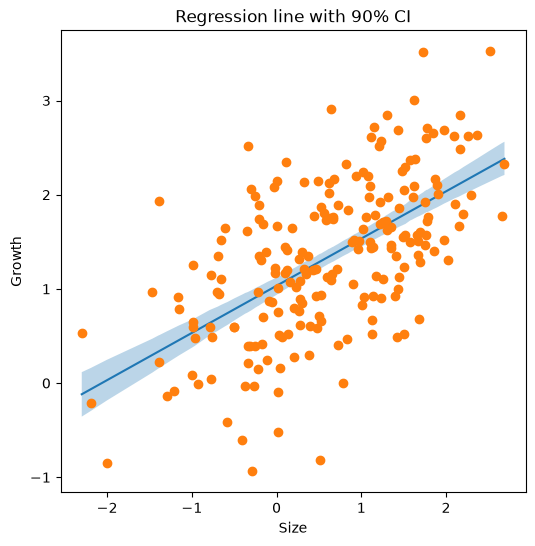

In [132]:
def plot_regression(x, y_mean, y_hpdi):
    # Sort values for plotting by x axis
    idx = jnp.argsort(x)
    size = x[idx]
    mean = y_mean[idx]
    hpdi = y_hpdi[:, idx]
    y = y_growth[idx]

    # Plot
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    ax.plot(size, mean)
    ax.plot(size, y, "o")
    ax.fill_between(size, hpdi[0], hpdi[1], alpha=0.3, interpolate=True)
    return ax


# Compute empirical posterior distribution over mu
posterior_mu = (
    jnp.expand_dims(samples["growth_int"], -1)
    + jnp.expand_dims(samples["growth_slope"], -1) * s_growth
)

mean_mu = jnp.mean(posterior_mu, axis=0)
hpdi_mu = hpdi(posterior_mu, 0.9)

ax = plot_regression(s_growth, mean_mu, hpdi_mu)
ax.set(
    xlabel="Size",
    ylabel="Growth",
    title="Regression line with 90% CI",
);